# Optimized Heart Failure Prediction (Gaussian Naive Bayes + Pipeline)

This notebook uses a highly optimized architecture. It utilizes an `imblearn.pipeline.Pipeline` to chain `StandardScaler`, `SMOTE`, and `GaussianNB`. This is the gold standard for cross-validation, ensuring zero data leakage when generating synthetic samples during Grid Search.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Set plotting style
sns.set_theme(style="whitegrid")

### 1. Data Preprocessing
We encode categorical variables and split the data. *Note: We no longer scale or apply SMOTE manually here. The Pipeline handles it to prevent data leakage.*

In [3]:
# Load the dataset
df = pd.read_csv('heart.csv')

# Perform One-Hot Encoding
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# We will define numerical columns for the scaler later if needed, but the Pipeline will scale all features, which is perfectly fine for Naive Bayes.

### 2. Build the imblearn Pipeline and Train
The Pipeline links scaling, SMOTE, and the classifier. During `GridSearchCV`, SMOTE is applied *independently* to each training fold, ensuring robust validation.

In [4]:
# Create the Pipeline
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('gnb', GaussianNB())
])

# Define hyperparameter grid for the gnb component in the pipeline
param_grid = {
    'gnb__var_smoothing': np.logspace(0, -9, num=20)
}

print("Training Pipeline with GridSearch...")
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_pipeline = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")

Training Pipeline with GridSearch...
Best Parameters Found: {'gnb__var_smoothing': np.float64(0.3359818286283782)}


### 3. Evaluation Metrics
Calculating Training vs. Testing accuracy to ensure generalization.

In [5]:
# Predict using the training data
y_train_pred = best_pipeline.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Predict using the unseen testing data
y_test_pred = best_pipeline.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Display the Results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

# Calculate the difference to evaluate generalization
difference = train_accuracy - test_accuracy
print(f"Difference:        {difference:.4f}\n")

print("Classification Report:\n", classification_report(y_test, y_test_pred))

Training Accuracy: 0.8678
Testing Accuracy:  0.8533
Difference:        0.0146

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83        77
           1       0.91      0.83      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



### 4. Final Visualizations
Confusion Matrix and Learning Curve.

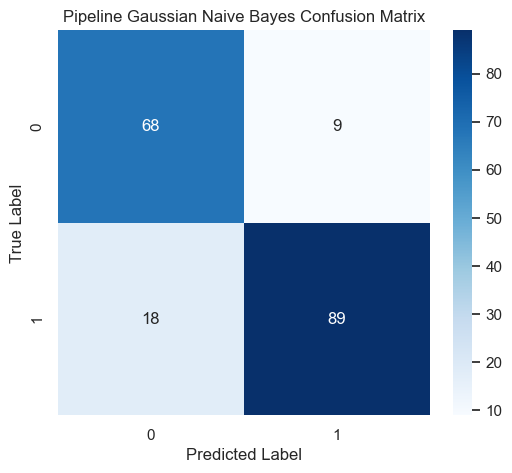

In [6]:
# --- VISUALIZATION 1: CONFUSION MATRIX ---
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Pipeline Gaussian Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

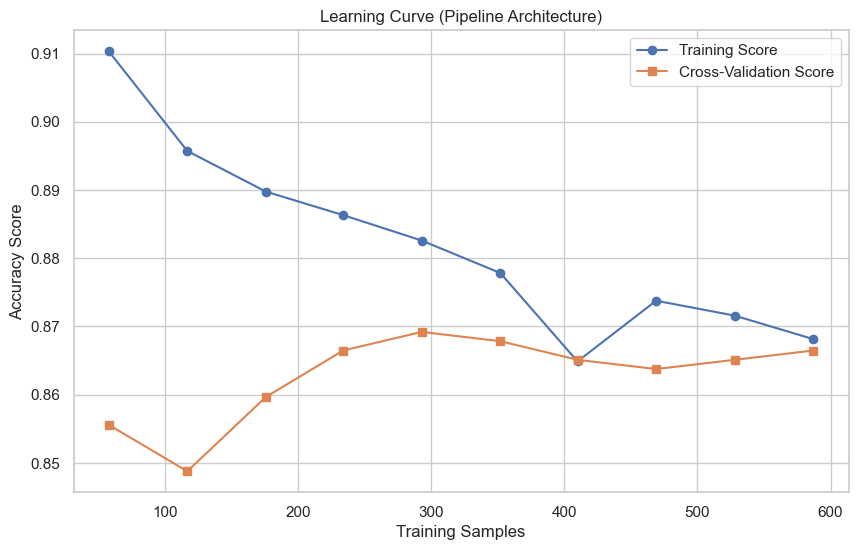

In [7]:
# --- VISUALIZATION 2: LEARNING CURVE ---
train_sizes, train_scores, test_scores = learning_curve(
    best_pipeline, X_train, y_train, cv=5, scoring='accuracy', 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', marker='s')
plt.title('Learning Curve (Pipeline Architecture)')
plt.xlabel('Training Samples')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()